In [7]:
import os

from typing import cast
from collections.abc import Mapping

from shimmer import SelectionBase
from shimmer_ssd.logging import batch_to_device
from shimmer_ssd.modules.domains.visual import VisualLatentDomainModule
from simple_shapes_dataset import SimpleShapesDataModule, get_default_domains

import io
import math
import numpy as np
import torch
from ipywidgets import interact
from PIL import Image
from torch.nn.functional import one_hot

from simple_shapes_dataset.cli import generate_image
from SSD_eval.SSD_utils import load_training_params_pickle, get_project_root

import sys
import os
from pathlib import Path

os.chdir(get_project_root())

# Ajoute SSD_eval au path pour que les imports internes aux scripts fonctionnent
ssd_eval_path = str(Path.cwd() / "SSD_eval")
if ssd_eval_path not in sys.path:
    sys.path.insert(0, ssd_eval_path)

# Maintenant tu peux importer tes fonctions
from SSD_eval.SSD_Train import setup_global_workspace, custom_collate_factory

%matplotlib widget


In [8]:
# get global workspace
project_name = "synesthesia"
experiment_name = "biased_80"

show_results_fusion = True
fusion_attr_weight = 0.5
n_samples = 32

training_params = load_training_params_pickle(project_name,  experiment_name)

exclude_colors = training_params["exclude_colors"]
checkpoint_path = Path("checkpoints")
gw_checkpoint_path = f"checkpoints/training_logs/{project_name}/{experiment_name}/checkpoints/last.ckpt"
config = training_params["config"]
hparams = training_params["hparams"] if "hparams" in training_params else {"temperature": 1, "alpha": 4}
apply_custom_init = training_params["apply_custom_init"]

global_workspace, domain_modules = setup_global_workspace(
    config,
    hparams,
    exclude_colors,
    apply_custom_init,
    load_from_checkpoint = True,
    gw_checkpoint_path = gw_checkpoint_path
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
global_workspace.to(device)


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Loading model from checkpoint: checkpoints/training_logs/synesthesia/biased_80/checkpoints/last.ckpt
Loaded default weights from checkpoints/training_logs/synesthesia/biased_80/checkpoints/last.ckpt


GlobalWorkspace2Domains(
  (gw_mod): GWModule(
    (domain_mods): ModuleDict(
      (v_latents): VisualLatentDomainModule(
        (visual_module): VisualDomainModule(
          (vae): VAE(
            (encoder): RAEEncoder(
              (layers): Sequential(
                (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
                (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (2): ReLU()
                (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
                (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (5): ReLU()
                (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
                (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (8): ReLU()
                (9): Conv2d(256, 512, kernel_size=(

In [9]:
# get data
domain_classes = get_default_domains(["v_latents", "attr"])

data_module = SimpleShapesDataModule(
    config.dataset.path,
    domain_classes,
    config.domain_proportions,
    config.training.batch_size,
    seed=config.seed,
    domain_args=config.domain_data_args,
    collate_fn=custom_collate_factory(exclude_colors=exclude_colors),
)

train_samples = data_module.get_samples("train", n_samples)
train_samples = batch_to_device(train_samples, device)



In [10]:
class FusionMethod(SelectionBase):
    def __init__(self, n_samples: int = 32, fusion_attr_weight: float = 0.5):
        super().__init__()
        self.n_samples = n_samples
        self.fusion_attr_weight = fusion_attr_weight
    def forward(
        self, domains: Mapping[str, torch.Tensor], encodings_pre_fusion: Mapping[str, torch.Tensor]
    ) -> dict[str, torch.Tensor]:
        # If only one domain, we keep it
        if len(domains) == 1:
            return {domain: torch.ones(self.n_samples).to(device) for domain in domains}
        else:
            selection: dict[str, torch.Tensor] = {}
            for domain in domains:
                # We only keep the visual latents
                if domain == "v_latents":
                    selection["v_latents"] = (torch.ones(self.n_samples)*(1 - self.fusion_attr_weight)).to(device)
                else:
                    # and set 0 to all other domain
                    selection[domain] = (torch.ones(self.n_samples)*self.fusion_attr_weight).to(device)
            return selection

In [11]:
# get translations: train samples to gw latent and fusion then back to modal
selection_mod = FusionMethod(n_samples, fusion_attr_weight)

visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])
train_paired_samples = train_samples[frozenset(["v_latents", "attr"])]

train_images = visual_module.decode_images(train_paired_samples["v_latents"])
train_attr = torch.cat((train_paired_samples["attr"][0], train_paired_samples["attr"][1]), dim=1)

unimodal_latents = global_workspace.encode_domains(train_samples)
gw_latents = global_workspace.encode(unimodal_latents)
gw_latents_fusion = global_workspace.encode_and_fuse(unimodal_latents, selection_mod)

gw_latents_decoded = global_workspace.decode(gw_latents[frozenset({'attr'})], ["v_latents", "attr"])
gw_latents_fusion_decoded = global_workspace.decode(gw_latents_fusion, ["v_latents", "attr"])

attr_decoded = gw_latents_decoded["attr"]["attr"]
images_decoded = visual_module.decode_images(gw_latents_decoded['attr']['v_latents'])

attr_fusion_decoded = gw_latents_fusion_decoded[frozenset({'v_latents', 'attr'})]['attr']
images_fusion_decoded = visual_module.decode_images(gw_latents_fusion_decoded[frozenset({'v_latents', 'attr'})]['v_latents'])

In [12]:
show_results_fusion = True

result_attr = attr_decoded
result_images = images_decoded

if show_results_fusion:
    result_attr = attr_fusion_decoded
    result_images = images_fusion_decoded

print(train_attr[0:3])
print(result_attr[0:3])

tensor([[ 1.0000,  0.0000,  0.0000,  0.1111, -0.4444, -0.4286,  0.8869, -0.4620],
        [ 1.0000,  0.0000,  0.0000,  0.6667,  0.0000,  0.7143,  0.9888, -0.1493],
        [ 0.0000,  1.0000,  0.0000, -0.3333, -0.8889,  1.0000,  0.3295,  0.9441]],
       device='cuda:0')
tensor([[ 7.5098, -5.3253, -5.5657,  0.1328, -0.4686, -0.4403,  0.8964, -0.4311],
        [ 7.8860, -5.2904, -8.6209,  0.6227,  0.0702,  0.7010,  0.9679, -0.1280],
        [-6.2132,  7.3880, -4.4177, -0.3437, -0.9230,  0.9898,  0.3728,  0.9319]],
       device='cuda:0', grad_fn=<SliceBackward0>)


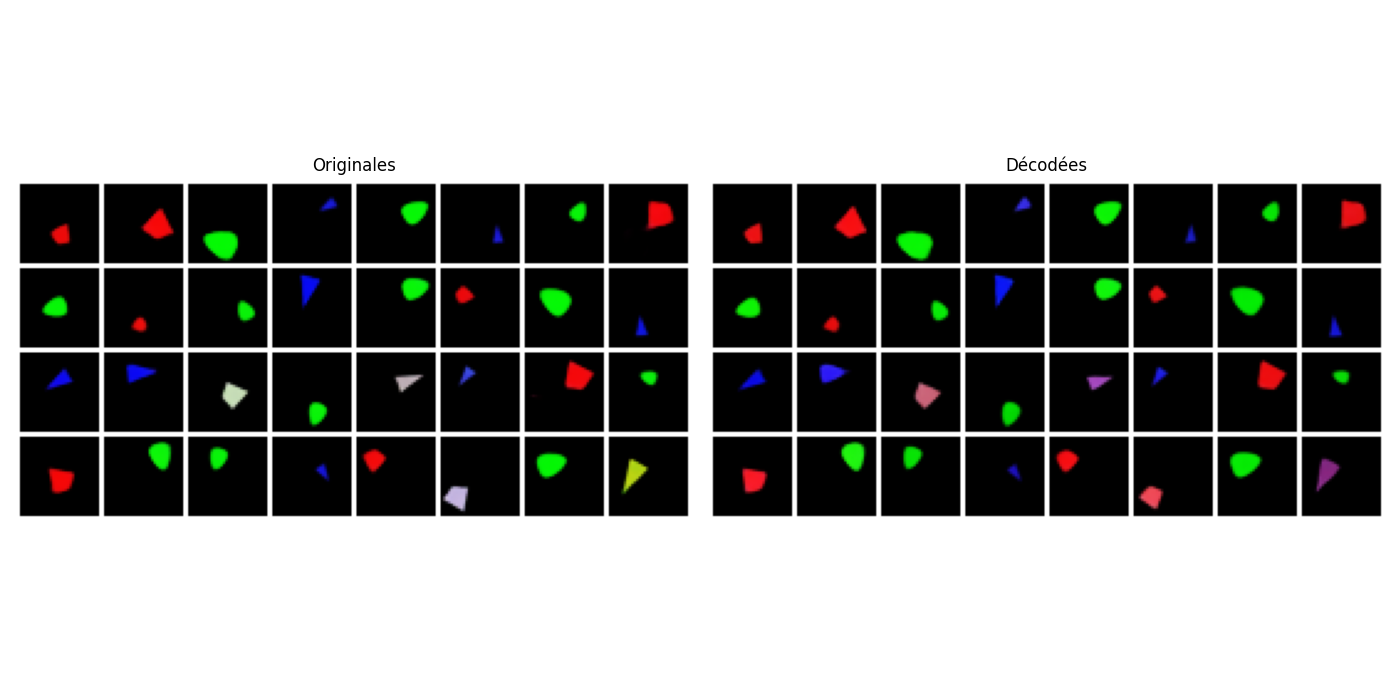

In [13]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid


def get_grid_numpy(samples, nrow=8):
    """Transforme les samples en grille numpy prête pour l'affichage"""
    grid = make_grid(samples, nrow=nrow, pad_value=1).permute(1, 2, 0)
    return grid.detach().cpu().numpy()

# 1. Préparation des données
grid_train = get_grid_numpy(train_images)
grid_decoded = get_grid_numpy(result_images)

# 2. Création d'une figure avec 2 lignes (subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7)) 

ax1.imshow(grid_train)
ax1.set_title("Originales")
ax1.axis('off')

ax2.imshow(grid_decoded)
ax2.set_title("Décodées")
ax2.axis('off')

plt.tight_layout()
plt.show()

interactive(children=(Dropdown(description='cat', options=('Triangle', 'Egg', 'Diamond'), value='Triangle'), F…

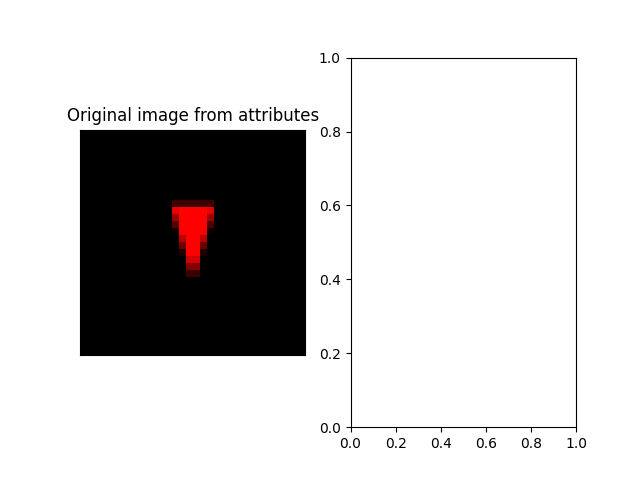

In [ ]:
%matplotlib widget
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
global_workspace.to(device)

cat2idx = {"Diamond": 0, "Egg": 1, "Triangle": 2}


def get_image(cat, x, y, size, rot, color_r, color_g, color_b):
    fig, ax = plt.subplots(figsize=(32, 32), dpi=1)
    # The dataset generatoion tool has function to generate a matplotlib shape
    # from the attributes. 
    generate_image(
        ax,
        cat2idx[cat],
        [int(x * 18 + 7), int(y * 18 + 7)],
        size * 7 + 7,
        rot * 2 * math.pi,
        np.array([color_r * 255, color_g * 255, color_b * 255]),
        imsize=32,
    )
    ax.set_facecolor("black")
    plt.tight_layout(pad=0)
    # Return this as a PIL Image.
    # This is to have the same dpi as saved images
    # otherwise matplotlib will render this in very high quality
    buf = io.BytesIO()
    fig.savefig(buf)
    buf.seek(0)
    image = Image.open(buf)
    plt.close(fig)
    return image


@interact(
    cat=["Triangle", "Egg", "Diamond"],
    x=(0, 1, 0.1),
    y=(0, 1, 0.1),
    rot=(0, 1, 0.1),
    size=(0, 1, 0.1),
    color_r=(0, 1, 0.1),
    color_g=(0, 1, 0.1),
    color_b=(0, 1, 0.1),
)
def play_with_gw(
    cat: str = "Triangle",
    x: float = 0.5,
    y: float = 0.5,
    rot: float = 0.5,
    size: float = 0.5,
    color_r: float = 1,
    color_g: float = 0,
    color_b: float = 0,
):
    fig, axes = plt.subplots(1, 2)
    image = get_image(cat, x, y, size, rot, color_r, color_g, color_b)
    axes[0].set_facecolor("black")
    axes[0].set_title("Original image from attributes")
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    axes[0].imshow(image)

    # normalize the attribute for the global workspace.
    category = one_hot(torch.tensor([cat2idx[cat]]), 3)
    rotx = math.cos(rot * 2 * math.pi)
    roty = math.sin(rot * 2 * math.pi)
    
    attributes = torch.tensor(
        [[x * 2 - 1, y * 2 - 1, size * 2 - 1, rotx, roty, ]]
    )

    if not exclude_colors:
        attributes = torch.tensor(
            [[x * 2 - 1, y * 2 - 1, size * 2 - 1, rotx, roty, color_r * 2 - 1, color_g * 2 - 1, color_b * 2 - 1]]
        )

    samples = [category.to(device), attributes.to(device)]
    attr_gw_latent = global_workspace.gw_mod.encode({"attr": global_workspace.encode_domain(samples, "attr")})
    gw_latent = global_workspace.gw_mod.fuse(
        attr_gw_latent, {"attr": torch.ones(attr_gw_latent["attr"].size(0)).to(device)}
    )
    decoded_latents = global_workspace.gw_mod.decode(gw_latent)["v_latents"]
    decoded_images = (
        global_workspace.domain_mods["v_latents"]
        .decode_images(decoded_latents)[0]
        .permute(1, 2, 0)
        .detach()
        .cpu()
        .numpy()
    )
    axes[1].imshow(decoded_images)
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    axes[1].set_title("Translated image through GW")
    plt.show()
